In [20]:
# 导入必要的库
import os
import numpy as np  # 用于数值计算，处理多维数组
import tensorflow as tf  # 深度学习框架，用于构建和训练神经网络模型
import pandas as pd  # 数据处理库，用于读取和处理CSV文件
from model import LSTM_, result, split_data# 导入自定义模块中的LSTM模型类、结果评估函数和数据拆分函数
from Optim import IPSO  # 导入自定义的改进粒子群优化算法
import matplotlib.pyplot as plt  # 绘图库，用于可视化数据
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # 数据预处理工具，用于特征缩放
from tensorflow.keras.optimizers import Adam
# 新增ARIMA相关库
# 新增ARIMA相关库 ← 修复完成
import warnings
warnings.filterwarnings("ignore")  # 忽略ARIMA拟合警告
from statsmodels.tsa.arima.model import ARIMA

# ===================== 【新增1】加权MSE损失（提升峰值精度） =====================
def peak_weighted_mse(y_true, y_pred):
    error = tf.abs(y_true - y_pred)
    # 对误差大于均值的样本给予2倍权重，误差越大权重越高
    weights = tf.where(error > tf.reduce_mean(error), 2.0, 1.0) * (1.0 + error)
    # 对负值预测额外惩罚
    penalty = tf.where(y_pred < 0, 10.0 * tf.abs(y_pred), 0.0)
    return tf.reduce_mean(tf.square(y_true - y_pred) * weights + penalty)

# 设置matplotlib的中文字体支持，确保图表能正确显示中文和负号
plt.rcParams['font.family'] = ['sans-serif']  # 设置字体为无衬线字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定无衬线字体为黑体（SimHei）
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

In [21]:
# 1. 数据加载与预处理
# 读取名为"三亚疫情.csv"的数据文件，跳过第一列（通常是索引列），用0填充缺失值，然后转换为numpy数组
# 时间列格式如：2023-11-18 22
raw_dataset_name = "data/time_hourly_statistics2_1.csv"
dataset_name = raw_dataset_name.split("/")[-1].split(".")[0]
data = pd.read_csv(raw_dataset_name).iloc[:, 1:].fillna(0).values

# 设置时间步长，即用过去多少个时间点的数据来预测未来的数据
time_steps = 12

in_, out_ = split_data(data, time_steps)
data.shape,in_.shape,out_.shape

((699, 1), (687, 12), (687, 1))

In [22]:
# 2. 数据集划分

train_size = int(in_.shape[0]*0.8)

train_data = in_[:train_size]  # 训练集输入
test_data = in_[train_size:]  # 测试集输入
train_label = out_[:train_size]  # 训练集标签（真实值）
test_label = out_[train_size:]  # 测试集标签（真实值）
train_data.shape,test_data.shape,train_label.shape,test_label.shape

((549, 12), (138, 12), (549, 1), (138, 1))

In [23]:
# 确保数据是二维的
if len(train_data.shape) > 2:
    # 如果是三维(samples, time_steps, features)，展平成二维
    original_shape = train_data.shape
    train_data_flat = train_data.reshape(original_shape[0], -1)
    test_data_flat = test_data.reshape(test_data.shape[0], -1)
    print(f"展平后train_data形状: {train_data_flat.shape}")
else:
    train_data_flat = train_data
    test_data_flat = test_data
# 3. 数据标准化

ss_X = StandardScaler().fit(train_data_flat)
# 对输出标签进行同样的标准化处理
ss_Y = MinMaxScaler(feature_range=(0, 1)).fit(train_label)


In [24]:
train_data = ss_X.transform(train_data_flat).reshape(train_data.shape[0], time_steps, -1)
train_label = ss_Y.transform(train_label)
# 用训练集的标准化器缩放测试集（而非重新拟合），保证训练 / 测试集的缩放规则一致，避免预测结果偏差。
test_data = ss_X.transform(test_data_flat).reshape(test_data.shape[0], time_steps, -1)
test_label = ss_Y.transform(test_label)
train_data.shape,train_label.shape,test_data.shape,test_label.shape

((549, 12, 1), (549, 1), (138, 12, 1), (138, 1))

In [26]:
# 4. IPSO优化超参数

# 定义结果保存路径（按数据集名称命名）
result_dir = "result"
ipso_result_path = os.path.join(result_dir, f"ipso_result_{dataset_name}1.npz")

optim_again = not os.path.exists(ipso_result_path)  
if optim_again: 
    trace, best, process= IPSO(train_data, train_label, test_data, test_label)
    
    # 将结果转换为numpy数组
    trace, process = np.array(trace), np.array(process)
    np.savez(ipso_result_path, trace=trace, best=best, process=process,dataset_name=dataset_name)
else:
    data = np.load(ipso_result_path)  
    trace = data['trace'].reshape(-1,)  # 重塑为一维数组
    process = data['process']  # 优化过程信息
    best = data['best' ].reshape(-1,)  # 最佳超参数，重塑为一维数组

Epoch 1/30
8/8 - 5s - loss: 0.0152 - 5s/epoch - 575ms/step
Epoch 2/30
8/8 - 0s - loss: 0.0112 - 47ms/epoch - 6ms/step
Epoch 3/30
8/8 - 0s - loss: 0.0099 - 47ms/epoch - 6ms/step
Epoch 4/30
8/8 - 0s - loss: 0.0095 - 47ms/epoch - 6ms/step
Epoch 5/30
8/8 - 0s - loss: 0.0085 - 46ms/epoch - 6ms/step
Epoch 6/30
8/8 - 0s - loss: 0.0086 - 47ms/epoch - 6ms/step
Epoch 7/30
8/8 - 0s - loss: 0.0082 - 47ms/epoch - 6ms/step
Epoch 8/30
8/8 - 0s - loss: 0.0077 - 48ms/epoch - 6ms/step
Epoch 9/30
8/8 - 0s - loss: 0.0075 - 46ms/epoch - 6ms/step
Epoch 10/30
8/8 - 0s - loss: 0.0075 - 47ms/epoch - 6ms/step
Epoch 11/30
8/8 - 0s - loss: 0.0074 - 48ms/epoch - 6ms/step
Epoch 12/30
8/8 - 0s - loss: 0.0074 - 47ms/epoch - 6ms/step
Epoch 13/30
8/8 - 0s - loss: 0.0072 - 46ms/epoch - 6ms/step
Epoch 14/30
8/8 - 0s - loss: 0.0069 - 47ms/epoch - 6ms/step
Epoch 15/30
8/8 - 0s - loss: 0.0068 - 46ms/epoch - 6ms/step
Epoch 16/30
8/8 - 0s - loss: 0.0065 - 46ms/epoch - 6ms/step
Epoch 17/30
8/8 - 0s - loss: 0.0069 - 47ms/epoch 

In [27]:
# 5. 设置随机种子以确保结果可重复
tf.random.set_seed(0)  # 设置TensorFlow的随机种子
np.random.seed(0)  # 设置NumPy的随机种子

# 从IPSO优化结果中提取最佳超参数
lr = best[0]  # 学习率
num_epochs = int(best[1])  # 训练轮数，转换为整数
batch_size = int(best[2])  # 批次大小，转换为整数
hidden_unit1  = int(best[3])  # 第一层LSTM隐藏单元数
hidden_unit2  = int(best[4])  # 第二层LSTM隐藏单元数
fc = int(best[5])  # 全连接层神经元数
# dropout1 = int(best[6])
# dropout2 = int(best[7]) 
print(f"{lr,num_epochs,batch_size,hidden_unit1,hidden_unit2,fc}")

(0.0016378280036578752, 62, 48, 17, 3, 65)


In [28]:
# 获取输入数据的形状信息
sequence, feature = train_data.shape[-2:]  # 时间步长和特征数
output_node = train_label.shape[1]  # 输出节点数（预测目标的数量）
sequence, feature,output_node

(12, 1, 1)

In [29]:
# 6. 构建LSTM模型
model = LSTM_(sequence, feature, hidden_unit1,hidden_unit2, fc, output_node).build_model()

model.compile(optimizer=Adam(learning_rate=lr), loss=peak_weighted_mse)


# 打印模型的结构摘要
model.summary()

Model: "model_167"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_168 (InputLayer)      [(None, 12, 1)]           0         
                                                                 
 bidirectional_334 (Bidirect  (None, 12, 34)           2584      
 ional)                                                          
                                                                 
 dropout_334 (Dropout)       (None, 12, 34)            0         
                                                                 
 bidirectional_335 (Bidirect  (None, 6)                912       
 ional)                                                          
                                                                 
 dropout_335 (Dropout)       (None, 6)                 0         
                                                                 
 dense_334 (Dense)           (None, 65)                45

Epoch 1/62
12/12 - 6s - loss: 0.0321 - val_loss: 0.0148 - 6s/epoch - 519ms/step
Epoch 2/62
12/12 - 0s - loss: 0.0278 - val_loss: 0.0136 - 116ms/epoch - 10ms/step
Epoch 3/62
12/12 - 0s - loss: 0.0270 - val_loss: 0.0130 - 108ms/epoch - 9ms/step
Epoch 4/62
12/12 - 0s - loss: 0.0267 - val_loss: 0.0122 - 108ms/epoch - 9ms/step
Epoch 5/62
12/12 - 0s - loss: 0.0243 - val_loss: 0.0118 - 108ms/epoch - 9ms/step
Epoch 6/62
12/12 - 0s - loss: 0.0239 - val_loss: 0.0112 - 111ms/epoch - 9ms/step
Epoch 7/62
12/12 - 0s - loss: 0.0224 - val_loss: 0.0108 - 108ms/epoch - 9ms/step
Epoch 8/62
12/12 - 0s - loss: 0.0230 - val_loss: 0.0108 - 108ms/epoch - 9ms/step
Epoch 9/62
12/12 - 0s - loss: 0.0223 - val_loss: 0.0106 - 107ms/epoch - 9ms/step
Epoch 10/62
12/12 - 0s - loss: 0.0215 - val_loss: 0.0102 - 108ms/epoch - 9ms/step
Epoch 11/62
12/12 - 0s - loss: 0.0219 - val_loss: 0.0098 - 108ms/epoch - 9ms/step
Epoch 12/62
12/12 - 0s - loss: 0.0207 - val_loss: 0.0095 - 109ms/epoch - 9ms/step
Epoch 13/62
12/12 - 0s - 

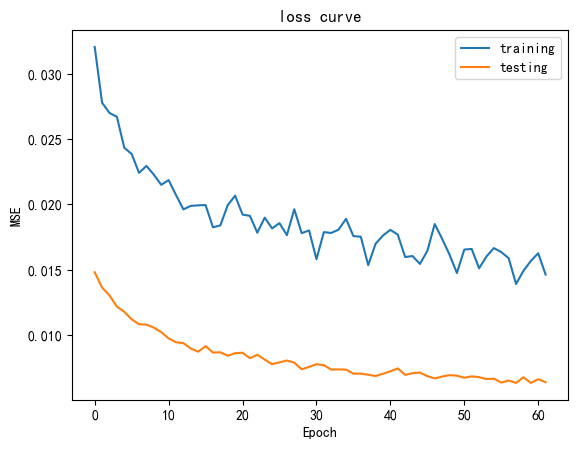

In [30]:
train_again = True  

if train_again:
    early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1)
    history = model.fit(train_data, train_label, epochs=num_epochs, validation_data=(test_data, test_label),
                        batch_size=batch_size, verbose=2,callbacks=[early_stop])
    model.save('model/ipso_lstm_model.h5')
    plt.figure()
    plt.ylabel('MSE')
    plt.xlabel('Epoch')
    plt.plot(history.history['loss'], label='training')
    plt.plot(history.history['val_loss'], label='testing')
    plt.title('loss curve')
    plt.legend()
    plt.savefig('figure/ipso_lstm_loss_curve.jpg')
else:  
    model = tf.keras.models.load_model('model/ipso_lstm_model.h5')

In [31]:
# 8. LSTM预测 & 提取残差 ←【修改点】
lstm_pred = model.predict(test_data)
test_label_reshaped = test_label.reshape(-1, 1)
lstm_pred_ori = ss_Y.inverse_transform(lstm_pred)
test_label_ori = ss_Y.inverse_transform(test_label_reshaped)

# 计算LSTM残差（真实值 - 预测值）←【新增】
residuals = test_label_ori - lstm_pred_ori

# ===================== 【优化4：ARIMA改为滚动预测+动态阶数选择】 =====================
# 修复后的ARIMA滚动预测函数
def arima_rolling_fit(residuals, arima_order=(1,1,1)):
    pred = np.zeros_like(residuals)
    hist = list(residuals[:10])
    
    for i in range(len(residuals)):
        if len(hist) >= max(arima_order):
            try:
                model_arima = ARIMA(hist, order=arima_order)
                fit = model_arima.fit()
                yhat = fit.forecast()[0]
                pred[i] = yhat
            except:
                pred[i] = np.mean(hist)
        else:
            pred[i] = np.mean(hist)
        hist.append(residuals[i])
    return pred

# 调用方式不变
arima_residual_pred = arima_rolling_fit(residuals.flatten()).reshape(-1, 1)

# 融合预测
alpha = 0.95  # LSTM权重
fusion_pred = alpha * lstm_pred_ori + (1 - alpha) * (lstm_pred_ori + arima_residual_pred)
fusion_pred = np.maximum(fusion_pred, 0)  # 兜底非负处理

# ======================================================

5/5 [==============================] - 1s 3ms/step


In [32]:
# 10. 保存预测结果

ipso_result_attention_path = os.path.join(result_dir,f"ipso_result_attention_{dataset_name}1.npz")
np.savez(ipso_result_attention_path, true=test_label_ori, pred=lstm_pred_ori, fusion_pred=fusion_pred)

# 11. 调整数据形状并评估模型性能

test_pred1 = lstm_pred_ori.reshape(-1, 1)
test_label1 = test_label_ori.reshape(-1, 1)
lstm_pred_ori.shape,test_label_ori.shape

((138, 1), (138, 1))

In [33]:
# 评估LSTM单独效果
print("\n========== LSTM 模型评估 ==========")
result(test_label_ori.reshape(-1,1), lstm_pred_ori.reshape(-1,1), 'IPSO_LSTM')

# 评估LSTM+ARIMA融合效果 ←【新增】
print("\n========== LSTM+ARIMA 融合模型评估 ==========")
result(test_label_ori.reshape(-1,1), fusion_pred.reshape(-1,1), 'IPSO_LSTM+ARIMA')


========== LSTM 模型评估 ==========
IPSO_LSTM 的mape:0.4240,rmse:0.2651,mae：0.1284

========== LSTM+ARIMA 融合模型评估 ==========
IPSO_LSTM+ARIMA 的mape:0.4270,rmse:0.2654,mae：0.1288


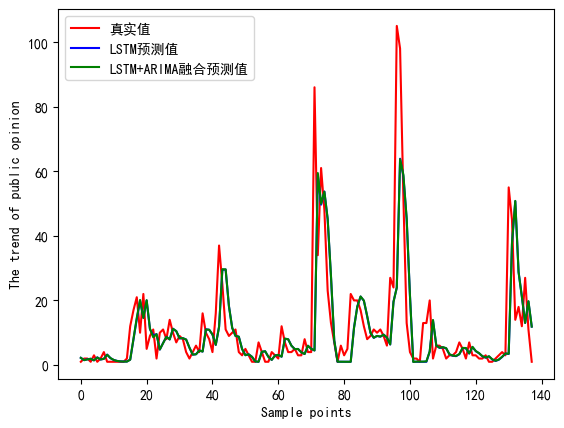

In [34]:
# 12. 可视化预测结果
fig_dir = "figure"
ipso_fig_predict = os.path.join(fig_dir,f"ipso_fig_predict_{dataset_name}1.png")
plt.figure()  # 创建一个新的图形
plt.plot(test_label_ori[:,0], c='r', label='真实值')
plt.plot(lstm_pred_ori[:,0], c='b', label='LSTM预测值')
plt.plot(fusion_pred[:,0], c='g', label='LSTM+ARIMA融合预测值')  # 新增绿色曲线
plt.legend()  # 显示图例
plt.xlabel('Sample points')  # 设置x轴标签
plt.ylabel('The trend of public opinion')  # 设置y轴标签
plt.savefig(ipso_fig_predict, dpi=500)  # 保存图形为高分辨率PNG文件
plt.show()  # 显示图形